# Day 12: Learning Rate, Optimization Intuition & Backpropagation

**Created on:** 2026-04-17

---
## 🎯 Objectives
- Understand **Learning Rate** and its impact
- Build intuition for **Convex vs Non-Convex Optimization**
- Learn **Chain Rule** (foundation of backpropagation)
- Understand **Backpropagation** step-by-step
- Explore **Vanishing & Exploding Gradients**
- Implement a **Mini Project (BFSI - Loan Risk Optimization)**

---


# 📌 1. Learning Rate (η)

## 🧠 Theory

Learning rate controls **how big a step** we take during gradient descent.

### Gradient Descent Rule:
```
theta = theta - learning_rate * gradient
```

### 🔍 Key Cases:
- **Too Small η** → Slow learning 🐢
- **Too Large η** → Divergence ❌
- **Optimal η** → Fast & stable convergence ✅

---
## 🌍 Real-Life Analogy

Adjusting shower temperature:
- Tiny adjustments → slow change
- Huge adjustments → unstable
- Balanced → comfortable quickly

---


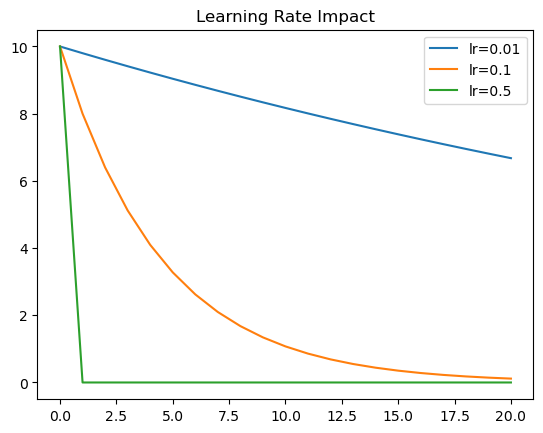

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def loss(x):
    return x**2

def gradient(x):
    return 2*x

def gradient_descent(start, lr, steps):
    x = start
    history = [x]
    for _ in range(steps):
        x = x - lr * gradient(x)
        history.append(x)
    return history

lrs = [0.01, 0.1, 0.5]

for lr in lrs:
    path = gradient_descent(10, lr, 20)
    plt.plot(path, label=f"lr={lr}")

plt.title("Learning Rate Impact")
plt.legend()
plt.show()


# 📌 2. Convex vs Non-Convex Optimization

## 🔵 Convex
- One global minimum
- Easy optimization

## 🔴 Non-Convex
- Multiple minima
- Saddle points
- Hard optimization

---
## 🧠 Intuition
- Convex → Smooth bowl
- Non-convex → Mountains & valleys 🌄


In [ ]:
def convex(x):
    return x**2

def non_convex(x):
    return x**4 - 3*x**3 + 2

x = np.linspace(-2, 3, 100)

plt.plot(x, convex(x), label="Convex")
plt.plot(x, non_convex(x), label="Non-Convex")
plt.legend()
plt.show()


# 📌 3. Chain Rule

## 🧠 Theory

If:
```
y = f(g(x))
```
Then:
```
dy/dx = f'(g(x)) * g'(x)
```

## Example:
```
y = (2x + 3)^2
dy/dx = 4(2x + 3)
```

## 🌍 Analogy
Study → Skills → Salary  
Total effect = multiply impacts


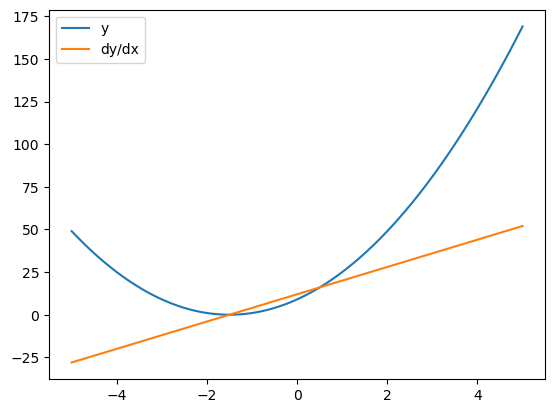

In [2]:
x = np.linspace(-5, 5, 100)
y = (2*x + 3)**2
dy_dx = 4*(2*x + 3)

plt.plot(x, y, label="y")
plt.plot(x, dy_dx, label="dy/dx")
plt.legend()
plt.show()


# 📌 4. Backpropagation

## 🧠 Theory

Backpropagation = Chain Rule applied across layers

### Steps:
1. Forward pass
2. Compute loss
3. Backward pass
4. Update weights

## 🔑 Key Idea:
Assign responsibility of error to each weight


In [4]:
# Simple backprop example

x = 2.0
w = 3.0

# Forward
z = x * w
loss = (z - 10)**2

# Backward
dL_dz = 2*(z - 10)
dz_dw = x
dL_dw = dL_dz * dz_dw

print("Gradient:", dL_dw)


Gradient: -16.0


# 📌 5. Vanishing & Exploding Gradients

## Vanishing:
- Gradients → 0
- No learning

## Exploding:
- Gradients → huge
- Unstable training


In [5]:
# Vanishing
v = 0.5
for i in range(10):
    v *= 0.5
    print("Vanishing:", v)

print()

# Exploding
v = 2
for i in range(10):
    v *= 2
    print("Exploding:", v)


Vanishing: 0.25
Vanishing: 0.125
Vanishing: 0.0625
Vanishing: 0.03125
Vanishing: 0.015625
Vanishing: 0.0078125
Vanishing: 0.00390625
Vanishing: 0.001953125
Vanishing: 0.0009765625
Vanishing: 0.00048828125

Exploding: 4
Exploding: 8
Exploding: 16
Exploding: 32
Exploding: 64
Exploding: 128
Exploding: 256
Exploding: 512
Exploding: 1024
Exploding: 2048


# 📌 6. Mini Project (Loan Risk Optimization)

## Goal:
Predict risk score and optimize using gradient descent

## Why BFSI?
- Risk scoring
- Fraud detection
- Credit modeling


0.37328322631924266
0.7235210749335707
1.052136297780699
1.3604638103956508
1.6497561146646709
1.9211883867947086
2.1758632511670504
2.414815259467662
2.6390150932895686
2.849373507279269
3.046745028845217
3.231931429457482
3.40568498163987
3.5687115148851976
3.721673282907594
3.8651916538793203
3.9998496345804995
4.126194238715474
4.244738709016472
4.3559646021613165
4.460323744974612
4.55824006985899
4.6501113369123805
4.736310749726964
4.817188471433586
4.893073047150176
4.964272738612498
5.031076776408829
5.093756534905471
5.152566634635896
5.207745976631731
5.259518712897269
5.308095156969823
5.353672638264831
5.396436303676283
5.436559869688758
5.474206328056341
5.509528607915052
5.542670197018464
5.573765724620103
5.60294150837046
5.630316067450226
5.656000604024242
5.680099454971929
5.7027105157292555
5.723925637963977
5.743831002699611
5.762507470403868
5.780030909463677
5.796472504381158


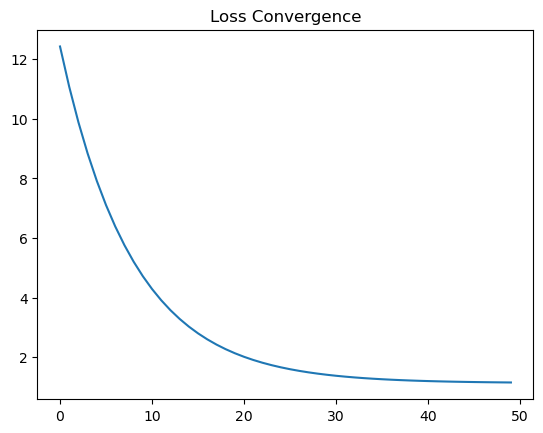

In [24]:
np.random.seed(42)

X = np.random.rand(100)
y_true = 3*X + 2

w = 0
lr = 0.1

losses = []

for i in range(50):
    y_pred = w * X 
    loss = np.mean((y_pred - y_true)**2)
    grad = np.mean(2*(y_pred - y_true)*X)

    w -= lr * grad
    print(w)
    losses.append(loss)

plt.plot(losses)
plt.title("Loss Convergence")
plt.show()


In [26]:
w = 0
b = 0
lr = 0.1
for i in range(500):
    y_pred = w * X + b

    loss = np.mean((y_pred - y_true)**2)

    grad_w = np.mean(2*(y_pred - y_true)*X)
    grad_b = np.mean(2*(y_pred - y_true))

    w -= lr * grad_w
    b -= lr * grad_b

    print(w, b)

0.37328322631924266 0.6821084460269256
0.6593782236900716 1.1926930858801865
0.879797167877448 1.5742575260546747
1.050727262500878 1.8587817295877331
1.184349089614459 2.0703274846230295
1.2898285610791393 2.226998806650503
1.374063281180094 2.342416981011601
1.442244123756539 2.4268304118374147
1.4982777733378265 2.4879496926487166
1.5451046530443222 2.5315759286948936
1.5849381395681175 2.5620734981097386
1.6194445531058044 2.5827257659805936
1.6498785852759426 2.5960027300435846
1.6771851977560015 2.603762402120027
1.7020762928708726 2.6074023311101784
1.7250884021323052 2.6079736115813774
1.7466260923338053 2.6062666658304887
1.7669946252697026 2.6028757877918594
1.7864245316813907 2.598247706969491
1.8050901013172842 2.5927181287435133
1.8231232953626895 2.586539227881335
1.8406242145744196 2.5799003350752416
1.8576689758621059 2.5729435017894122
1.874315638934927 2.565775211454159
1.890608665779486 2.5584751911022874
1.9065822762106621 2.551103041326059
1.9222629728052778 2.5437